# Step 01 — SQLite post-fit pipeline and hidden-mechanism summaries

This notebook reruns the **legacy single-current post-fit summaries** used for reviewer-response context.

## Reuse from `astro_atf_analysis_improved_sectioned.ipynb`

None of the ATF parsing, preprocessing, or sweep-feature extraction logic is reused here.  
This step interprets the **historical Optuna DB summaries**, not the new ATF dataset.

## Interpretation boundary

Because historical control provenance remains unresolved in step 00, the outputs below should be treated as:
- structural-confounding diagnostics,
- effective-parameter summaries,
- and provisional mechanism narratives,

not as final reviewer-facing mechanism proof.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", Path.cwd())).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.postfit_sqlite import d_pk_invariance_check, run_step01_postfit_sqlite

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

PROJECT_ROOT

PosixPath('/mnt/data/astromodel_proving_updated')

In [2]:
results = run_step01_postfit_sqlite(PROJECT_ROOT)
top_trials_df = results["top_trials_all_dbs"]
effective_df = results["effective_parameter_summary"]
representative_df = results["representative_mechanism_summary"]

print("written outputs:", sorted((PROJECT_ROOT / "outputs" / "postfit_sqlite").glob("*.csv")))
print("top-trial rows:", len(top_trials_df), "effective rows:", len(effective_df), "representative rows:", len(representative_df))

written outputs: [PosixPath('/mnt/data/astromodel_proving_updated/outputs/postfit_sqlite/effective_parameter_summary.csv'), PosixPath('/mnt/data/astromodel_proving_updated/outputs/postfit_sqlite/representative_mechanism_summary.csv'), PosixPath('/mnt/data/astromodel_proving_updated/outputs/postfit_sqlite/top_trials_all_dbs.csv')]
top-trial rows: 18 effective rows: 18 representative rows: 3


## `d × pk` confounding check

In [3]:
base_params = {
    "gki": 50.0,
    "pk": 2e-4,
    "d": 3.0,
    "gt": 8.0,
    "gs": 10.0,
    "zth": 0.2,
    "zs": 0.05,
    "K_bath_value_middle": 8.2,
    "eps": 0.01,
    "eps_middle": 0.5,
    "wo": 1500.0,
    "ca": 400.0,
    "gl_a": 0.01,
    "Va_l": -70.0,
    "Va_s": -90.0,
    "switching_function": "sigmoid",
}
check = d_pk_invariance_check(base_params)
display(
    pd.DataFrame(
        [
            {
                "P_gap_eff_a": check.P_gap_eff_a,
                "P_gap_eff_b": check.P_gap_eff_b,
                "I_kgap_a": check.I_kgap_a,
                "I_kgap_b": check.I_kgap_b,
                "max_abs_rhs_delta": float(abs(check.dzdt_a - check.dzdt_b).max()),
            }
        ]
    )
)

,P_gap_eff_a,P_gap_eff_b,I_kgap_a,I_kgap_b,max_abs_rhs_delta
0,0.0006,0.0006,1866.960713,1866.960713,0.0


## Effective parameter summary (all 18 DBs)

,db_name,study_name,condition,current_na,trial_id,trial_number,objective,P_gap_eff,gamma_t_eff,gamma_s_eff,volume_ratio_wa_wo
0,BARIUM_50nA.db,BARIUM_50nA_centered_L2_20000t_20240930_133313,BARIUM,50,1,0,3450.286230,3.820129e-04,0.000077,0.000047,2.776433
1,BARIUM_75nA.db,BARIUM_75nA_centered_L2_20000t_20240930_133312,BARIUM,75,1,0,5848.293742,5.145793e-04,0.000033,0.000319,2.274250
2,BARIUM_100nA.db,BARIUM_100nA_centered_L2_20000t_20240930_133313,BARIUM,100,1,0,7963.653221,3.060630e-04,0.000057,0.000329,2.888380
3,BARIUM_125nA.db,BARIUM_125nA_centered_L2_20000t_20240930_133313,BARIUM,125,1,0,13492.704819,2.694143e-04,0.000048,0.000112,1.585457
4,BARIUM_150nA.db,BARIUM_150nA_centered_L2_20000t_20240930_133313,BARIUM,150,4312,4311,23509.572968,2.099761e-04,0.000058,0.000255,3.071149
5,BARIUM_175nA.db,BARIUM_175nA_centered_L2_20000t_20240930_133313,BARIUM,175,1,0,28903.238239,3.980285e-04,0.000030,0.000016,1.585018
6,CONTROL_50nA.db,CONTROL_50nA_centered_L2_2500t,CONTROL,50,2068,2067,21.502226,4.282360e-06,0.000052,0.000091,1.308028
7,CONTROL_75nA.db,CONTROL_75nA_centered_L2_2500t,CONTROL,75,2426,2425,30.054498,7.688695e-06,0.000008,0.000069,1.527016
8,CONTROL_100nA.db,CONTROL_100nA_centered_L2_2500t,CONTROL,100,1944,1943,38.365141,4.567634e-08,0.000026,0.000080,1.465699
9,CONTROL_125nA.db,CONTROL_125nA_centered_L2_2500t,CONTROL,125,1930,1929,102.645495,6.177250e-08,0.000008,0.000131,1.014964


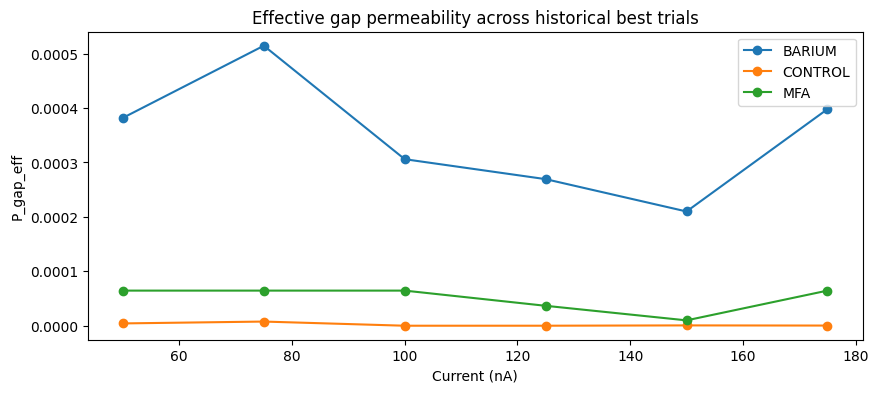

In [4]:
display(effective_df)

fig, ax = plt.subplots(figsize=(10, 4))
for condition, group in effective_df.groupby("condition"):
    ax.plot(group["current_na"], group["P_gap_eff"], marker="o", label=condition)
ax.set_xlabel("Current (nA)")
ax.set_ylabel("P_gap_eff")
ax.set_title("Effective gap permeability across historical best trials")
ax.legend()
plt.show()

## Representative mechanism summary

,db_name,study_name,condition,current_na,trial_id,trial_number,objective,P_gap_eff,gamma_t_eff,gamma_s_eff,volume_ratio_wa_wo,I_Kir_integral,I_kgap_integral,I_leak_integral,I_k_a_integral,I_Kir_peak_abs,I_kgap_peak_abs,gap_to_kir_integral_ratio,gap_kir_classification,gap_fraction,kir_fraction,leak_fraction,K_o_baseline,K_o_peak,K_o_final,K_o_delta_peak,K_o_recovery_error,dominant_mechanism,proxy_proxy,proxy_target,proxy_pearson_r,proxy_spearman_r,proxy_rmse_after_scaling,proxy_lag_s_at_max_corr,proxy_validity_class
0,BARIUM_100nA.db,BARIUM_100nA_centered_L2_20000t_20240930_133313,BARIUM,100,1,0,7963.653221,0.000306,0.000057,0.000329,2.888380,765.766317,12897.041463,12132.667975,0.0,180.187123,860.144335,16.842007,gap_dominant,0.499973,0.029686,0.470341,4.8,7.596770,4.877359,2.796770,0.077359,Mixed,DK_a_t,K_o,0.999925,1.00000,0.007149,0.0,strong
1,CONTROL_75nA.db,CONTROL_75nA_centered_L2_2500t,CONTROL,75,2426,2425,30.054498,0.000008,0.000008,0.000069,1.527016,1542.868912,1892.971968,358.014013,0.0,89.057630,100.638353,1.226917,mixed,0.498957,0.406676,0.094367,4.8,8.395908,5.109484,3.595908,0.309484,Mixed,DK_a_t,K_o,0.454297,1.00000,0.265254,0.0,weak
2,MFA_100nA.db,MFA_100nA_centered_COMBINED_20000t_2024-10-13_...,MFA,100,1,0,135164.788205,0.000065,0.000018,0.001280,0.190203,12337.933214,15019.795557,2686.617004,0.0,628.860053,760.533826,1.217367,mixed,0.499921,0.410657,0.089422,4.8,7.971894,4.553637,3.171894,0.246363,Mixed,DK_a_t,K_o,0.339423,-0.32304,0.322408,0.0,failed


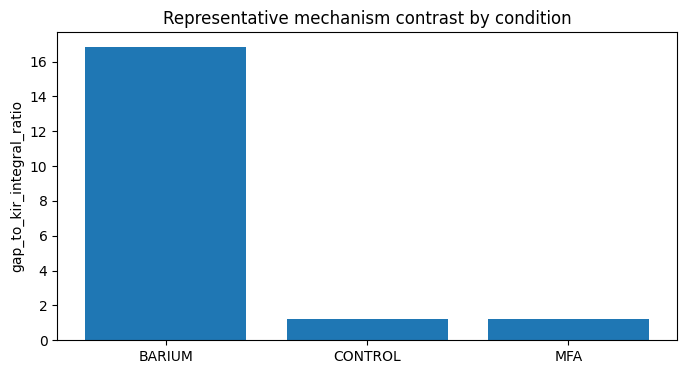

In [5]:
display(representative_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(representative_df["condition"], representative_df["gap_to_kir_integral_ratio"])
ax.set_ylabel("gap_to_kir_integral_ratio")
ax.set_title("Representative mechanism contrast by condition")
plt.show()

## Consequence for the reviewer response

Step 01 still supports the mechanistic framing that **effective combinations** matter more than raw `d` or `pk` alone.  
However, because it is built on legacy single-current fits — and because historical control provenance is still unresolved — the strongest reviewer-facing evidence among steps 00-02 remains the ATF-based step 02 thresholds and region summaries.